# SECOM — Robust Extra Trees: Nested CV, Stability, Threshold Analysis & SHAP

This notebook focuses **only on Extra Trees** and keeps the earlier rigorous SECOM setup.

## Core setup retained
- Official UCI SECOM loading
- 80/20 stratified split with untouched test set
- Constant-feature removal
- >50% missingness filtering
- Mann–Whitney U screening
- Benjamini–Hochberg FDR
- Effect-size screening
- Spearman redundancy pruning
- Median imputation + missingness indicators
- Class-weighted Extra Trees
- OOF threshold selection

## New robustness work
1. **Nested cross-validation** for less optimistic model selection.
2. **Multiple repeated stratified splits** to measure stability.
3. **False-alarm analysis** and operating-point selection.
4. **Process-state features** based on training-set robust standardized sensor deviations and missingness burden.
5. **SHAP explanations** for global and individual Extra Trees predictions.
6. Final untouched-test evaluation only after all model/threshold decisions.

> SECOM variables are anonymized. Feature importance/SHAP identifies model-associated signals, not proven physical root causes.


In [1]:


%pip -q install -U imbalanced-learn scikit-learn matplotlib seaborn shap


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 25.2 MB/s eta 0:00:00


In [2]:
# 2. Imports

import io
import zipfile
import urllib.request
import warnings
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_val_predict
)
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from imblearn.pipeline import Pipeline

import shap

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Imports successful.")
print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)
print("SHAP  :", shap.__version__)


Imports successful.
NumPy : 2.1.3
Pandas: 2.2.3
SHAP  : 0.52.0


In [3]:
# 3. Load official UCI SECOM data

URL = "https://archive.ics.uci.edu/static/public/179/secom.zip"

def load_secom():
    with urllib.request.urlopen(URL, timeout=60) as response:
        raw = response.read()

    with zipfile.ZipFile(io.BytesIO(raw)) as z:
        names = z.namelist()

        def locate(filename):
            matches = [n for n in names if n.lower().endswith(filename.lower())]
            if not matches:
                raise FileNotFoundError(
                    f"{filename} not found in official UCI archive."
                )
            return matches[0]

        data_file = locate("secom.data")
        label_file = locate("secom_labels.data")

        with z.open(data_file) as f:
            X = pd.read_csv(f, sep=r"\s+", header=None, engine="python")

        # The UCI labels file has: label date time
        with z.open(label_file) as f:
            labels = pd.read_csv(
                f,
                sep=r"\s+",
                header=None,
                names=["label", "date", "time"],
                engine="python"
            )

    if len(X) != len(labels):
        raise ValueError(f"Row mismatch: X={len(X)}, labels={len(labels)}")

    X.columns = [f"Sensor_{i+1}" for i in range(X.shape[1])]

    # -1 = pass, +1 = fail
    y = (labels["label"].astype(int) == 1).astype(int)

    timestamps = (
        labels["date"].astype(str).str.strip('"')
        + " "
        + labels["time"].astype(str).str.strip('"')
    )

    return X, y, timestamps

X, y, timestamps = load_secom()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts().sort_index())
print(f"Failure rate: {y.mean():.2%}")

assert X.shape == (1567, 590)
assert len(y) == 1567
assert int(y.sum()) == 104

print("✅ SECOM loaded correctly.")


X shape: (1567, 590)
y shape: (1567,)

Class distribution:
label
0    1463
1     104
Name: count, dtype: int64
Failure rate: 6.64%
✅ SECOM loaded correctly.


Features: 590
Constant features: 116
Features >50% missing: 28
Total missing cells: 41951


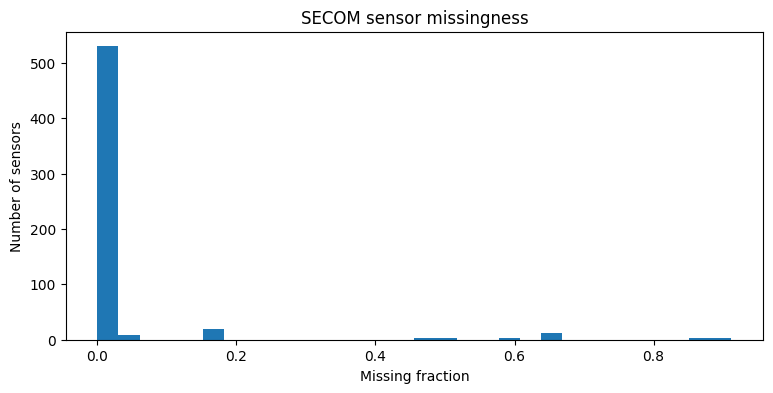

In [4]:
# 4. Basic data quality

missing_fraction = X.isna().mean()
constant_features = X.columns[X.nunique(dropna=True) <= 1].tolist()

print("Features:", X.shape[1])
print("Constant features:", len(constant_features))
print("Features >50% missing:", int((missing_fraction > 0.50).sum()))
print("Total missing cells:", int(X.isna().sum().sum()))

plt.figure(figsize=(9, 4))
plt.hist(missing_fraction, bins=30)
plt.xlabel("Missing fraction")
plt.ylabel("Number of sensors")
plt.title("SECOM sensor missingness")
plt.show()


In [5]:
# 5. Untouched stratified test set

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print("Train:", X_train.shape, "failures:", int(y_train.sum()))
print("Test :", X_test.shape, "failures:", int(y_test.sum()))
print(f"Train failure rate: {y_train.mean():.2%}")
print(f"Test failure rate : {y_test.mean():.2%}")


Train: (1253, 590) failures: 83
Test : (314, 590) failures: 21
Train failure rate: 6.62%
Test failure rate : 6.69%


## 6. Leakage-free statistical feature selector

This selector is deliberately implemented as an sklearn transformer so it is fitted separately inside each CV training fold.

Pipeline:
**quality filtering → Mann–Whitney → BH/FDR → effect size → rank AUC ranking → Spearman pruning**.


In [6]:
class StatisticalFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        missing_threshold=0.50,
        fdr_alpha=0.05,
        min_effect=0.15,
        max_features=80,
        corr_threshold=0.90,
        min_features=10
    ):
        self.missing_threshold = missing_threshold
        self.fdr_alpha = fdr_alpha
        self.min_effect = min_effect
        self.max_features = max_features
        self.corr_threshold = corr_threshold
        self.min_features = min_features

    @staticmethod
    def bh_adjust(p):
        p = np.asarray(p, dtype=float)
        n = len(p)
        order = np.argsort(p)
        ranked = p[order]
        q = ranked * n / np.arange(1, n + 1)
        q = np.minimum.accumulate(q[::-1])[::-1]
        out = np.empty(n)
        out[order] = np.clip(q, 0, 1)
        return out

    @staticmethod
    def rank_auc(a, b):
        n0, n1 = len(a), len(b)
        if n0 == 0 or n1 == 0:
            return 0.5

        values = np.concatenate([a, b])
        ranks = pd.Series(values).rank(method="average").to_numpy()
        u = ranks[n0:].sum() - n1 * (n1 + 1) / 2
        auc = u / (n0 * n1)
        return float(max(auc, 1 - auc))

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        y = pd.Series(np.asarray(y)).reset_index(drop=True)
        X.reset_index(drop=True, inplace=True)

        self.feature_names_in_ = np.asarray(X.columns, dtype=object)

        # Quality filters fit only on the current training fold.
        candidates = X.columns[X.nunique(dropna=True) > 1].tolist()
        candidates = [
            c for c in candidates
            if X[c].isna().mean() <= self.missing_threshold
        ]

        if not candidates:
            raise ValueError("No features survive quality filtering.")

        Xi = X[candidates].replace([np.inf, -np.inf], np.nan)
        Xi = Xi.fillna(Xi.median()).fillna(0)

        neg = y.to_numpy() == 0
        pos = y.to_numpy() == 1

        rows = []

        for feature in candidates:
            a = Xi.loc[neg, feature].to_numpy()
            b = Xi.loc[pos, feature].to_numpy()

            try:
                _, p_value = mannwhitneyu(
                    a, b,
                    alternative="two-sided"
                )
                auc = self.rank_auc(a, b)
            except Exception:
                p_value = 1.0
                auc = 0.5

            scale = np.nanstd(Xi[feature].to_numpy(), ddof=1)

            if np.isfinite(scale) and scale > 1e-12:
                effect = abs(
                    np.nanmedian(b) - np.nanmedian(a)
                ) / scale
            else:
                effect = 0.0

            rows.append((feature, p_value, effect, auc))

        stats = pd.DataFrame(
            rows,
            columns=["feature", "p_value", "effect", "auc"]
        )

        stats["q_value"] = self.bh_adjust(stats["p_value"])
        stats["auc_distance"] = (stats["auc"] - 0.5).abs()

        selected = stats[
            (stats["q_value"] <= self.fdr_alpha) &
            (stats["effect"] >= self.min_effect)
        ].copy()

        # Safe fallback if the strict gate is too small.
        if len(selected) < self.min_features:
            selected = stats.sort_values(
                ["q_value", "auc_distance", "effect"],
                ascending=[True, False, False]
            ).head(min(self.max_features, len(stats)))

        selected = selected.sort_values(
            ["q_value", "auc_distance", "effect"],
            ascending=[True, False, False]
        ).head(self.max_features)

        names = selected["feature"].tolist()

        # Correlation pruning is learned only from this training fold.
        if len(names) > 1:
            corr = Xi[names].corr(method="spearman").abs()
            kept = []

            for feature in names:
                if all(
                    corr.loc[feature, prior] < self.corr_threshold
                    for prior in kept
                ):
                    kept.append(feature)

            names = kept

        if not names:
            names = [stats.sort_values("q_value").iloc[0]["feature"]]

        self.selected_features_ = names
        self.statistics_ = (
            stats.sort_values("q_value")
            .reset_index(drop=True)
        )

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        return X[self.selected_features_].copy()

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.selected_features_, dtype=object)


In [7]:
# 7. Optional process-state feature transformer

# These features are training-data-derived:
# - missing count / missing fraction
# - count/fraction of sensors with large robust deviations
# - median/max robust deviation across sensors
#
# Robust centers/scales are fitted only on the training fold.

class ProcessStateFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, z_threshold=3.0):
        self.z_threshold = z_threshold

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.columns_ = list(X.columns)

        X_num = X.replace([np.inf, -np.inf], np.nan)

        self.medians_ = X_num.median()
        self.q1_ = X_num.quantile(0.25)
        self.q3_ = X_num.quantile(0.75)

        iqr = self.q3_ - self.q1_
        self.scales_ = iqr.replace(0, np.nan)

        # Fallback to standard deviation where IQR is zero.
        std = X_num.std(ddof=1)
        self.scales_ = self.scales_.fillna(std)
        self.scales_ = self.scales_.replace(0, np.nan).fillna(1.0)

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X_num = X.replace([np.inf, -np.inf], np.nan)

        med = self.medians_.reindex(self.columns_)
        scale = self.scales_.reindex(self.columns_)

        robust_z = (X_num[self.columns_] - med) / scale
        abs_z = robust_z.abs()

        missing_count = X_num[self.columns_].isna().sum(axis=1)
        missing_fraction = X_num[self.columns_].isna().mean(axis=1)

        abnormal_count = (abs_z > self.z_threshold).sum(axis=1)
        abnormal_fraction = (abs_z > self.z_threshold).mean(axis=1)

        state = pd.DataFrame({
            "Process_Missing_Count": missing_count,
            "Process_Missing_Fraction": missing_fraction,
            "Process_Abnormal_Count": abnormal_count,
            "Process_Abnormal_Fraction": abnormal_fraction,
            "Process_Median_Abs_Robust_Z": abs_z.median(axis=1),
            "Process_Max_Abs_Robust_Z": abs_z.max(axis=1)
        }, index=X.index)

        return pd.concat([X.reset_index(drop=True),
                           state.reset_index(drop=True)], axis=1)


## 8. Two Extra Trees pipelines

We compare:

**A. Earlier exact setup**
- statistical selection
- imputation + missingness indicators
- class-weighted Extra Trees

**B. Enhanced process-state setup**
- same statistical selection
- imputation
- process-state anomaly features
- class-weighted Extra Trees

This lets us determine whether the new process-state features actually help.


In [8]:
def new_selector():
    return StatisticalFeatureSelector(
        missing_threshold=0.50,
        fdr_alpha=0.05,
        min_effect=0.15,
        max_features=80,
        corr_threshold=0.90,
        min_features=10
    )

def make_extra_trees(use_process_state=False):
    steps = [
        ("selector", new_selector()),
        ("imputer", SimpleImputer(
            strategy="median",
            add_indicator=True
        ))
    ]

    if use_process_state:
        steps.append(
            ("process_state", ProcessStateFeatures(z_threshold=3.0))
        )

    steps.append(
        ("model", ExtraTreesClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced",
            n_jobs=-1,
            random_state=SEED
        ))
    )

    return Pipeline(steps)

exact_model = make_extra_trees(use_process_state=False)
enhanced_model = make_extra_trees(use_process_state=True)

models = {
    "ExtraTrees_ExactSetup": exact_model,
    "ExtraTrees_ProcessState": enhanced_model
}

print("Models ready.")


Models ready.


## 9. Nested cross-validation

The outer folds estimate generalization.

Inside each outer training fold, we choose the best feature/process-state setup using inner CV.

The final untouched test set is still not used.

Because we have only two closely related model variants, the nested experiment is intentionally small and transparent.


X_train: (1253, 590)
X_test : (314, 590)
Train failures: 83
Test failures : 21
✅ Feature-name check passed.

✅ Models created:
   ExtraTrees_ExactSetup
   ExtraTrees_ProcessState

Testing ProcessState pipeline before nested CV...
Debug probability shape: (200,)
✅ ProcessState pipeline sanity test passed.

OUTER FOLD 1
Outer train: (1002, 590) | failures: 66
Outer validation: (251, 590) | failures: 17

  Inner CV → ExtraTrees_ExactSetup
    Threshold = 0.1300
    BA        = 0.6854
    ROC-AUC   = 0.7345
    PR-AUC    = 0.1556
    Recall    = 0.6667
    Precision = 0.1371

  Inner CV → ExtraTrees_ProcessState
    Threshold = 0.1350
    BA        = 0.7115
    ROC-AUC   = 0.7506
    PR-AUC    = 0.1672
    Recall    = 0.6667
    Precision = 0.1618

  ✅ Chosen model: ExtraTrees_ProcessState
  ✅ Chosen threshold: 0.135

OUTER FOLD 2
Outer train: (1002, 590) | failures: 66
Outer validation: (251, 590) | failures: 17

  Inner CV → ExtraTrees_ExactSetup
    Threshold = 0.1150
    BA        = 0.

,outer_fold,selected_model,selected_threshold,inner_pr_auc,balanced_accuracy,roc_auc,pr_auc,recall,precision,f1,false_positives,false_negatives
0,1,ExtraTrees_ProcessState,0.135,0.1672,0.5985,0.6262,0.1345,0.4706,0.1111,0.1798,64,9
1,2,ExtraTrees_ExactSetup,0.115,0.1407,0.6312,0.7129,0.2533,0.6471,0.1089,0.1864,90,6
2,3,ExtraTrees_ExactSetup,0.120,0.1400,0.6488,0.7411,0.2394,0.5882,0.1282,0.2105,68,7
3,4,ExtraTrees_ProcessState,0.105,0.1917,0.7388,0.8176,0.1843,0.8750,0.1308,0.2276,93,2
4,5,ExtraTrees_ProcessState,0.135,0.1999,0.6338,0.7236,0.2278,0.5625,0.1154,0.1915,69,7



NESTED CV — MEAN ± STD


,mean,std
balanced_accuracy,0.6502,0.0528
roc_auc,0.7243,0.0684
pr_auc,0.2078,0.0484
recall,0.6287,0.1517
precision,0.1189,0.0100
f1,0.1992,0.0196



MODEL SELECTION FREQUENCY


,times_selected
ExtraTrees_ProcessState,3
ExtraTrees_ExactSetup,2



THRESHOLD STABILITY


,outer_fold,selected_model,selected_threshold
0,1,ExtraTrees_ProcessState,0.135
1,2,ExtraTrees_ExactSetup,0.115
2,3,ExtraTrees_ExactSetup,0.120
3,4,ExtraTrees_ProcessState,0.105
4,5,ExtraTrees_ProcessState,0.135



OVERALL OUTER-OOF PERFORMANCE
Balanced Accuracy : 0.6492
ROC-AUC           : 0.7211
PR-AUC            : 0.1712
Recall            : 0.6265
Precision         : 0.1193
F1                : 0.2004

Model used for final threshold graph: ExtraTrees_ProcessState


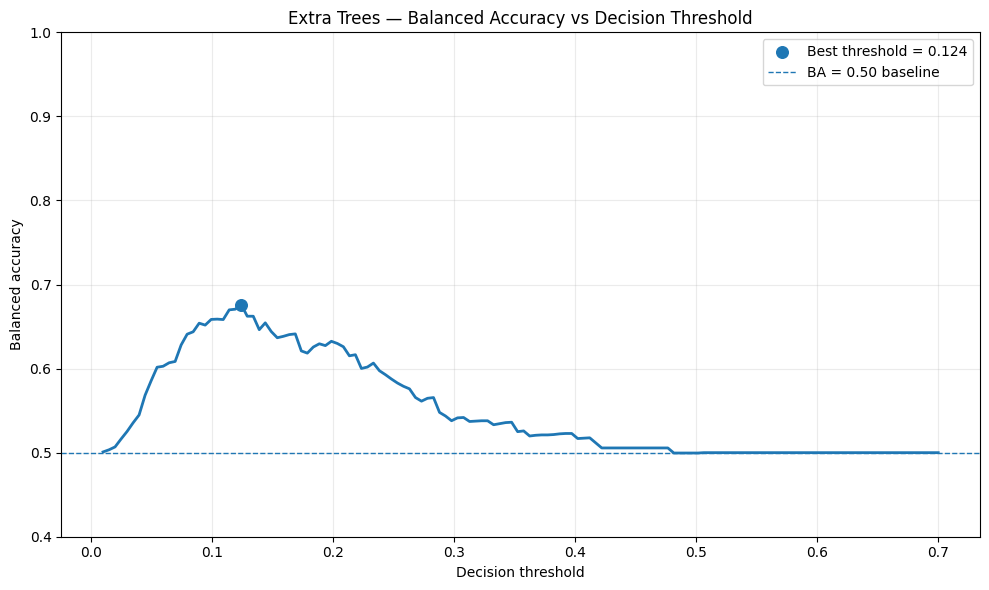

Best OOF threshold: 0.124
Best OOF balanced accuracy: 0.6762


In [10]:
# ============================================================
# EXTRA TREES ROBUST PIPELINE
# - Statistical feature selection
# - Process-state features
# - Nested CV
# - Threshold selection INSIDE inner CV
# - No mixed pandas column-name types
# ============================================================

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin, clone

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)

from sklearn.impute import SimpleImputer

from sklearn.ensemble import ExtraTreesClassifier

from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from scipy.stats import mannwhitneyu

from imblearn.pipeline import Pipeline


# ============================================================
# 1. CLEAN TRAIN / TEST DATA
# ============================================================

X_train = X_train.copy()
X_test = X_test.copy()

# Force ALL feature names to strings.
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

y_train = pd.Series(
    np.asarray(y_train)
).reset_index(drop=True)

y_test = pd.Series(
    np.asarray(y_test)
).reset_index(drop=True)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Train failures:", int(y_train.sum()))
print("Test failures :", int(y_test.sum()))

assert all(
    isinstance(c, str)
    for c in X_train.columns
)

assert all(
    isinstance(c, str)
    for c in X_test.columns
)

print("✅ Feature-name check passed.")


# ============================================================
# 2. STATISTICAL FEATURE SELECTOR
# ============================================================

class StatisticalFeatureSelector(
    BaseEstimator,
    TransformerMixin
):

    def __init__(
        self,
        missing_threshold=0.50,
        fdr_alpha=0.05,
        min_effect=0.15,
        max_features=80,
        corr_threshold=0.90,
        min_features=10
    ):

        self.missing_threshold = missing_threshold
        self.fdr_alpha = fdr_alpha
        self.min_effect = min_effect
        self.max_features = max_features
        self.corr_threshold = corr_threshold
        self.min_features = min_features


    @staticmethod
    def bh_adjust(p):

        p = np.asarray(
            p,
            dtype=float
        )

        n = len(p)

        if n == 0:
            return np.array([])

        order = np.argsort(p)

        ranked = p[order]

        q = (
            ranked
            * n
            / np.arange(1, n + 1)
        )

        q = np.minimum.accumulate(
            q[::-1]
        )[::-1]

        q = np.clip(
            q,
            0,
            1
        )

        output = np.empty(n)

        output[order] = q

        return output


    @staticmethod
    def rank_auc(a, b):

        n0 = len(a)
        n1 = len(b)

        if n0 == 0 or n1 == 0:
            return 0.5

        values = np.concatenate(
            [a, b]
        )

        ranks = (
            pd.Series(values)
            .rank(method="average")
            .to_numpy()
        )

        u = (
            ranks[n0:].sum()
            - n1 * (n1 + 1) / 2
        )

        auc = (
            u
            / (n0 * n1)
        )

        return float(
            max(
                auc,
                1 - auc
            )
        )


    def fit(self, X, y):

        # Always convert to DataFrame
        X = pd.DataFrame(X).copy()

        # IMPORTANT:
        # force all names to strings
        X.columns = [
            str(c)
            for c in X.columns
        ]

        X.reset_index(
            drop=True,
            inplace=True
        )

        y = pd.Series(
            np.asarray(y)
        ).reset_index(drop=True)

        self.feature_names_in_ = np.asarray(
            X.columns,
            dtype=object
        )

        # ----------------------------------------------------
        # Remove constant features
        # ----------------------------------------------------

        candidates = [
            c
            for c in X.columns
            if X[c].nunique(
                dropna=True
            ) > 1
        ]

        # ----------------------------------------------------
        # Missingness filtering
        # ----------------------------------------------------

        candidates = [
            c
            for c in candidates
            if X[c].isna().mean()
            <= self.missing_threshold
        ]

        if len(candidates) == 0:
            raise ValueError(
                "No features survived quality filtering."
            )

        # ----------------------------------------------------
        # Temporary imputation ONLY for statistics
        # ----------------------------------------------------

        Xi = (
            X[candidates]
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
        )

        Xi = (
            Xi
            .fillna(Xi.median())
            .fillna(0)
        )

        negative = (
            y.to_numpy() == 0
        )

        positive = (
            y.to_numpy() == 1
        )

        rows = []

        for feature in candidates:

            a = Xi.loc[
                negative,
                feature
            ].to_numpy()

            b = Xi.loc[
                positive,
                feature
            ].to_numpy()

            try:

                _, p_value = (
                    mannwhitneyu(
                        a,
                        b,
                        alternative="two-sided"
                    )
                )

                auc = self.rank_auc(
                    a,
                    b
                )

            except Exception:

                p_value = 1.0
                auc = 0.5

            scale = np.nanstd(
                Xi[feature].to_numpy(),
                ddof=1
            )

            if (
                np.isfinite(scale)
                and scale > 1e-12
            ):

                effect = (
                    abs(
                        np.nanmedian(b)
                        - np.nanmedian(a)
                    )
                    / scale
                )

            else:

                effect = 0.0

            rows.append(
                (
                    str(feature),
                    p_value,
                    effect,
                    auc
                )
            )

        statistics = pd.DataFrame(
            rows,
            columns=[
                "feature",
                "p_value",
                "effect",
                "auc"
            ]
        )

        statistics["q_value"] = (
            self.bh_adjust(
                statistics["p_value"]
            )
        )

        statistics["auc_distance"] = (
            statistics["auc"]
            - 0.5
        ).abs()

        # ----------------------------------------------------
        # Statistical selection
        # ----------------------------------------------------

        selected = statistics[
            (
                statistics["q_value"]
                <= self.fdr_alpha
            )
            &
            (
                statistics["effect"]
                >= self.min_effect
            )
        ].copy()

        # ----------------------------------------------------
        # Fallback
        # ----------------------------------------------------

        if len(selected) < self.min_features:

            selected = (
                statistics
                .sort_values(
                    [
                        "q_value",
                        "auc_distance",
                        "effect"
                    ],
                    ascending=[
                        True,
                        False,
                        False
                    ]
                )
                .head(
                    min(
                        self.max_features,
                        len(statistics)
                    )
                )
            )

        selected = (
            selected
            .sort_values(
                [
                    "q_value",
                    "auc_distance",
                    "effect"
                ],
                ascending=[
                    True,
                    False,
                    False
                ]
            )
            .head(
                self.max_features
            )
        )

        selected_names = [
            str(c)
            for c in selected[
                "feature"
            ].tolist()
        ]

        # ----------------------------------------------------
        # Spearman correlation pruning
        # ----------------------------------------------------

        if len(selected_names) > 1:

            corr = (
                Xi[selected_names]
                .corr(
                    method="spearman"
                )
                .abs()
            )

            kept = []

            for feature in selected_names:

                if all(
                    corr.loc[
                        feature,
                        previous
                    ]
                    < self.corr_threshold
                    for previous in kept
                ):

                    kept.append(
                        feature
                    )

            selected_names = kept

        # ----------------------------------------------------
        # Final fallback
        # ----------------------------------------------------

        if len(selected_names) == 0:

            selected_names = [
                str(
                    statistics
                    .sort_values(
                        "q_value"
                    )
                    .iloc[0]["feature"]
                )
            ]

        self.selected_features_ = [
            str(c)
            for c in selected_names
        ]

        self.statistics_ = (
            statistics
            .sort_values(
                "q_value"
            )
            .reset_index(drop=True)
        )

        return self


    def transform(self, X):

        X = pd.DataFrame(X).copy()

        # Always strings
        X.columns = [
            str(c)
            for c in X.columns
        ]

        selected = [
            str(c)
            for c in self.selected_features_
        ]

        missing = [
            c
            for c in selected
            if c not in X.columns
        ]

        if missing:

            raise ValueError(
                "Selected features missing: "
                + str(missing[:10])
            )

        result = (
            X[selected]
            .copy()
        )

        result.columns = [
            str(c)
            for c in result.columns
        ]

        return result


    def get_feature_names_out(
        self,
        input_features=None
    ):

        return np.asarray(
            [
                str(c)
                for c
                in self.selected_features_
            ],
            dtype=object
        )


# ============================================================
# 3. PROCESS-STATE FEATURE ENGINEERING
# ============================================================

class ProcessStateFeatures(
    BaseEstimator,
    TransformerMixin
):

    def __init__(
        self,
        z_threshold=3.0
    ):

        self.z_threshold = z_threshold


    def fit(
        self,
        X,
        y=None
    ):

        X = pd.DataFrame(X).copy()

        X.columns = [
            str(c)
            for c in X.columns
        ]

        self.columns_ = [
            str(c)
            for c in X.columns
        ]

        X_num = (
            X[self.columns_]
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
        )

        # Training-fold statistics only
        self.medians_ = (
            X_num.median()
        )

        q1 = (
            X_num.quantile(
                0.25
            )
        )

        q3 = (
            X_num.quantile(
                0.75
            )
        )

        iqr = (
            q3 - q1
        )

        std = (
            X_num.std(
                ddof=1
            )
        )

        self.scales_ = iqr.copy()

        bad_scale = (
            self.scales_.isna()
            |
            (
                self.scales_
                <= 1e-12
            )
        )

        self.scales_[
            bad_scale
        ] = std[
            bad_scale
        ]

        self.scales_ = (
            self.scales_
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
            .fillna(1.0)
        )

        return self


    def transform(self, X):

        X = pd.DataFrame(X).copy()

        X.columns = [
            str(c)
            for c in X.columns
        ]

        missing = [
            c
            for c in self.columns_
            if c not in X.columns
        ]

        if missing:

            raise ValueError(
                "Process-state features missing columns: "
                + str(missing[:10])
            )

        X_num = (
            X[self.columns_]
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
        )

        med = (
            self.medians_
            .reindex(
                self.columns_
            )
        )

        scale = (
            self.scales_
            .reindex(
                self.columns_
            )
        )

        robust_z = (
            X_num - med
        ) / scale

        abs_z = (
            robust_z.abs()
        )

        # ----------------------------------------------------
        # Missingness state
        # ----------------------------------------------------

        missing_count = (
            X_num
            .isna()
            .sum(axis=1)
        )

        missing_fraction = (
            X_num
            .isna()
            .mean(axis=1)
        )

        # ----------------------------------------------------
        # Abnormal sensor state
        # ----------------------------------------------------

        abnormal_mask = (
            abs_z
            > self.z_threshold
        )

        abnormal_count = (
            abnormal_mask
            .sum(axis=1)
        )

        abnormal_fraction = (
            abnormal_mask
            .mean(axis=1)
        )

        median_abs_z = (
            abs_z
            .median(
                axis=1,
                skipna=True
            )
        )

        max_abs_z = (
            abs_z
            .max(
                axis=1,
                skipna=True
            )
        )

        # ----------------------------------------------------
        # Create process-state features
        # ----------------------------------------------------

        state = pd.DataFrame({

            "Process_Missing_Count":
                missing_count.to_numpy(),

            "Process_Missing_Fraction":
                missing_fraction.to_numpy(),

            "Process_Abnormal_Count":
                abnormal_count.to_numpy(),

            "Process_Abnormal_Fraction":
                abnormal_fraction.to_numpy(),

            "Process_Median_Abs_Robust_Z":
                median_abs_z.to_numpy(),

            "Process_Max_Abs_Robust_Z":
                max_abs_z.to_numpy()

        })

        state.columns = [
            str(c)
            for c in state.columns
        ]

        # ----------------------------------------------------
        # Combine original selected features + state features
        # ----------------------------------------------------

        result = pd.concat(
            [
                X_num.reset_index(
                    drop=True
                ),

                state.reset_index(
                    drop=True
                )
            ],
            axis=1
        )

        # FINAL safety check
        result.columns = [
            str(c)
            for c in result.columns
        ]

        assert all(
            isinstance(c, str)
            for c in result.columns
        )

        return result


    def get_feature_names_out(
        self,
        input_features=None
    ):

        return np.asarray(
            self.columns_
            + [
                "Process_Missing_Count",
                "Process_Missing_Fraction",
                "Process_Abnormal_Count",
                "Process_Abnormal_Fraction",
                "Process_Median_Abs_Robust_Z",
                "Process_Max_Abs_Robust_Z"
            ],
            dtype=object
        )


# ============================================================
# 4. SELECTOR FACTORY
# ============================================================

def new_selector():

    return StatisticalFeatureSelector(

        missing_threshold=0.50,

        fdr_alpha=0.05,

        min_effect=0.15,

        max_features=80,

        corr_threshold=0.90,

        min_features=10
    )


# ============================================================
# 5. EXTRA TREES PIPELINES
# ============================================================

def make_extra_trees(
    use_process_state=False
):

    steps = [

        (
            "selector",
            new_selector()
        )
    ]

    # IMPORTANT:
    # Process-state features are created BEFORE imputation.
    if use_process_state:

        steps.append(
            (
                "process_state",
                ProcessStateFeatures(
                    z_threshold=3.0
                )
            )
        )

    # Imputation happens after state features.
    steps.append(
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        )
    )

    # Final model
    steps.append(
        (
            "model",
            ExtraTreesClassifier(

                n_estimators=500,

                min_samples_leaf=2,

                max_features="sqrt",

                class_weight="balanced",

                n_jobs=-1,

                random_state=SEED
            )
        )
    )

    return Pipeline(
        steps
    )


exact_model = make_extra_trees(
    use_process_state=False
)

enhanced_model = make_extra_trees(
    use_process_state=True
)


models = {

    "ExtraTrees_ExactSetup":
        exact_model,

    "ExtraTrees_ProcessState":
        enhanced_model

}

print("\n✅ Models created:")
for name in models:
    print("  ", name)


# ============================================================
# 6. SANITY TEST PROCESS-STATE PIPELINE
# ============================================================

print("\nTesting ProcessState pipeline before nested CV...")

debug_X = (
    X_train
    .iloc[:200]
    .copy()
)

debug_y = (
    y_train
    .iloc[:200]
    .copy()
)

debug_X.columns = (
    debug_X.columns
    .astype(str)
)

debug_model = clone(
    enhanced_model
)

debug_model.fit(
    debug_X,
    debug_y
)

debug_probability = (
    debug_model
    .predict_proba(
        debug_X
    )[:, 1]
)

print(
    "Debug probability shape:",
    debug_probability.shape
)

assert len(debug_probability) == len(
    debug_X
)

print(
    "✅ ProcessState pipeline sanity test passed."
)


# ============================================================
# 7. NESTED CROSS-VALIDATION
# ============================================================

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

inner_cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=SEED + 1
)


# ============================================================
# 8. THRESHOLD SEARCH
# ============================================================

def find_best_threshold(
    y_true,
    probability
):

    rows = []

    thresholds = np.linspace(
        0.02,
        0.70,
        137
    )

    for threshold in thresholds:

        prediction = (
            probability >= threshold
        ).astype(int)

        rows.append({

            "threshold":
                threshold,

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_true,
                    prediction
                ),

            "recall":
                recall_score(
                    y_true,
                    prediction,
                    zero_division=0
                ),

            "precision":
                precision_score(
                    y_true,
                    prediction,
                    zero_division=0
                ),

            "f1":
                f1_score(
                    y_true,
                    prediction,
                    zero_division=0
                )
        })

    table = pd.DataFrame(
        rows
    )

    best = (
        table
        .sort_values(
            [
                "balanced_accuracy",
                "recall",
                "precision"
            ],
            ascending=[
                False,
                False,
                False
            ]
        )
        .iloc[0]
    )

    return (
        float(
            best["threshold"]
        ),
        table
    )


# ============================================================
# 9. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    y_true,
    probability,
    threshold
):

    prediction = (
        probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            prediction,
            labels=[0, 1]
        )
        .ravel()
    )

    return {

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                prediction
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                probability
            ),

        "pr_auc":
            average_precision_score(
                y_true,
                probability
            ),

        "recall":
            recall_score(
                y_true,
                prediction,
                zero_division=0
            ),

        "precision":
            precision_score(
                y_true,
                prediction,
                zero_division=0
            ),

        "f1":
            f1_score(
                y_true,
                prediction,
                zero_division=0
            ),

        "false_positives":
            fp,

        "false_negatives":
            fn
    }


# ============================================================
# 10. STORAGE
# ============================================================

nested_rows = []

nested_oof_probability = np.zeros(
    len(X_train),
    dtype=float
)

nested_oof_threshold = np.zeros(
    len(X_train),
    dtype=float
)

outer_model_choices = []

outer_thresholds = []

inner_threshold_tables = {}


# ============================================================
# 11. OUTER CV
# ============================================================

for outer_fold, (
    train_idx,
    validation_idx
) in enumerate(
    outer_cv.split(
        X_train,
        y_train
    ),
    start=1
):

    print("\n" + "=" * 75)
    print(
        f"OUTER FOLD {outer_fold}"
    )
    print("=" * 75)

    # --------------------------------------------------------
    # Outer training
    # --------------------------------------------------------

    X_outer_train = (
        X_train
        .iloc[train_idx]
        .copy()
    )

    y_outer_train = (
        y_train
        .iloc[train_idx]
        .copy()
    )

    # --------------------------------------------------------
    # Outer validation
    # --------------------------------------------------------

    X_outer_val = (
        X_train
        .iloc[validation_idx]
        .copy()
    )

    y_outer_val = (
        y_train
        .iloc[validation_idx]
        .copy()
    )

    # Force strings one more time.
    X_outer_train.columns = (
        X_outer_train.columns
        .astype(str)
    )

    X_outer_val.columns = (
        X_outer_val.columns
        .astype(str)
    )

    print(
        "Outer train:",
        X_outer_train.shape,
        "| failures:",
        int(y_outer_train.sum())
    )

    print(
        "Outer validation:",
        X_outer_val.shape,
        "| failures:",
        int(y_outer_val.sum())
    )


    # ========================================================
    # INNER CV MODEL + THRESHOLD SELECTION
    # ========================================================

    inner_candidates = {}

    for model_name, candidate in models.items():

        print(
            f"\n  Inner CV → {model_name}"
        )

        # Generate OOF probabilities inside outer training data.
        inner_probability = (
            cross_val_predict(

                estimator=clone(
                    candidate
                ),

                X=X_outer_train,

                y=y_outer_train,

                cv=inner_cv,

                method="predict_proba",

                n_jobs=1
            )[:, 1]
        )

        # ----------------------------------------------------
        # Threshold is selected HERE.
        # ----------------------------------------------------

        best_threshold, threshold_table = (
            find_best_threshold(
                y_outer_train,
                inner_probability
            )
        )

        inner_metrics = calculate_metrics(
            y_outer_train,
            inner_probability,
            best_threshold
        )

        inner_candidates[
            model_name
        ] = {

            "threshold":
                best_threshold,

            "metrics":
                inner_metrics,

            "threshold_table":
                threshold_table
        }

        print(
            f"    Threshold = "
            f"{best_threshold:.4f}"
        )

        print(
            f"    BA        = "
            f"{inner_metrics['balanced_accuracy']:.4f}"
        )

        print(
            f"    ROC-AUC   = "
            f"{inner_metrics['roc_auc']:.4f}"
        )

        print(
            f"    PR-AUC    = "
            f"{inner_metrics['pr_auc']:.4f}"
        )

        print(
            f"    Recall    = "
            f"{inner_metrics['recall']:.4f}"
        )

        print(
            f"    Precision = "
            f"{inner_metrics['precision']:.4f}"
        )


    # ========================================================
    # MODEL SELECTION
    # ========================================================

    chosen_name = max(

        inner_candidates,

        key=lambda name:
            inner_candidates[
                name
            ]["metrics"]["pr_auc"]

    )

    chosen_threshold = (
        inner_candidates[
            chosen_name
        ]["threshold"]
    )

    print(
        "\n  ✅ Chosen model:",
        chosen_name
    )

    print(
        "  ✅ Chosen threshold:",
        round(
            chosen_threshold,
            4
        )
    )

    outer_model_choices.append(
        chosen_name
    )

    outer_thresholds.append(
        chosen_threshold
    )

    inner_threshold_tables[
        outer_fold
    ] = {
        name:
            data["threshold_table"]
        for name, data
        in inner_candidates.items()
    }


    # ========================================================
    # REFIT ON FULL OUTER TRAINING FOLD
    # ========================================================

    chosen_model = clone(
        models[chosen_name]
    )

    chosen_model.fit(
        X_outer_train,
        y_outer_train
    )


    # ========================================================
    # OUTER VALIDATION
    # ========================================================

    outer_probability = (
        chosen_model
        .predict_proba(
            X_outer_val
        )[:, 1]
    )

    outer_metrics = calculate_metrics(

        y_outer_val,

        outer_probability,

        chosen_threshold

    )

    outer_metrics[
        "outer_fold"
    ] = outer_fold

    outer_metrics[
        "selected_model"
    ] = chosen_name

    outer_metrics[
        "selected_threshold"
    ] = chosen_threshold

    outer_metrics[
        "inner_pr_auc"
    ] = inner_candidates[
        chosen_name
    ]["metrics"]["pr_auc"]

    nested_rows.append(
        outer_metrics
    )

    nested_oof_probability[
        validation_idx
    ] = outer_probability

    nested_oof_threshold[
        validation_idx
    ] = chosen_threshold


# ============================================================
# 12. NESTED CV FOLD RESULTS
# ============================================================

nested_results = pd.DataFrame(
    nested_rows
)

print("\n" + "=" * 75)
print("NESTED CV — FOLD RESULTS")
print("=" * 75)

display(
    nested_results[
        [
            "outer_fold",
            "selected_model",
            "selected_threshold",
            "inner_pr_auc",
            "balanced_accuracy",
            "roc_auc",
            "pr_auc",
            "recall",
            "precision",
            "f1",
            "false_positives",
            "false_negatives"
        ]
    ].round(4)
)


# ============================================================
# 13. NESTED CV MEAN ± STD
# ============================================================

metric_columns = [

    "balanced_accuracy",

    "roc_auc",

    "pr_auc",

    "recall",

    "precision",

    "f1"

]

nested_summary = pd.DataFrame({

    "mean":
        nested_results[
            metric_columns
        ].mean(),

    "std":
        nested_results[
            metric_columns
        ].std()

})

print("\n" + "=" * 75)
print("NESTED CV — MEAN ± STD")
print("=" * 75)

display(
    nested_summary.round(4)
)


# ============================================================
# 14. MODEL SELECTION FREQUENCY
# ============================================================

print("\n" + "=" * 75)
print("MODEL SELECTION FREQUENCY")
print("=" * 75)

model_frequency = (
    pd.Series(
        outer_model_choices
    )
    .value_counts()
)

display(
    model_frequency.to_frame(
        "times_selected"
    )
)


# ============================================================
# 15. THRESHOLD STABILITY
# ============================================================

print("\n" + "=" * 75)
print("THRESHOLD STABILITY")
print("=" * 75)

threshold_summary = pd.DataFrame({

    "outer_fold":
        np.arange(
            1,
            len(outer_thresholds) + 1
        ),

    "selected_model":
        outer_model_choices,

    "selected_threshold":
        outer_thresholds

})

display(
    threshold_summary.round(4)
)


# ============================================================
# 16. OVERALL OUTER-OOF PERFORMANCE
# ============================================================

overall_oof_roc_auc = (
    roc_auc_score(
        y_train,
        nested_oof_probability
    )
)

overall_oof_pr_auc = (
    average_precision_score(
        y_train,
        nested_oof_probability
    )
)

overall_oof_prediction = (
    nested_oof_probability
    >= nested_oof_threshold
).astype(int)

overall_oof_ba = (
    balanced_accuracy_score(
        y_train,
        overall_oof_prediction
    )
)

overall_oof_recall = (
    recall_score(
        y_train,
        overall_oof_prediction,
        zero_division=0
    )
)

overall_oof_precision = (
    precision_score(
        y_train,
        overall_oof_prediction,
        zero_division=0
    )
)

overall_oof_f1 = (
    f1_score(
        y_train,
        overall_oof_prediction,
        zero_division=0
    )

)

print("\n" + "=" * 75)
print("OVERALL OUTER-OOF PERFORMANCE")
print("=" * 75)

print(
    f"Balanced Accuracy : "
    f"{overall_oof_ba:.4f}"
)

print(
    f"ROC-AUC           : "
    f"{overall_oof_roc_auc:.4f}"
)

print(
    f"PR-AUC            : "
    f"{overall_oof_pr_auc:.4f}"
)

print(
    f"Recall            : "
    f"{overall_oof_recall:.4f}"
)

print(
    f"Precision         : "
    f"{overall_oof_precision:.4f}"
)

print(
    f"F1                : "
    f"{overall_oof_f1:.4f}"
)


# ============================================================
# 17. BALANCED ACCURACY VS THRESHOLD GRAPH
# ============================================================

# Use the model that was selected most frequently by nested CV.
final_candidate_name = (
    model_frequency.index[0]
)

print(
    "\nModel used for final threshold graph:",
    final_candidate_name
)

# Fresh OOF probabilities using the entire training data.
final_oof_probability = (
    cross_val_predict(

        estimator=clone(
            models[
                final_candidate_name
            ]
        ),

        X=X_train,

        y=y_train,

        cv=outer_cv,

        method="predict_proba",

        n_jobs=1

    )[:, 1]
)

threshold_graph_rows = []

for threshold in np.linspace(
    0.01,
    0.70,
    140
):

    prediction = (
        final_oof_probability
        >= threshold
    ).astype(int)

    threshold_graph_rows.append({

        "threshold":
            threshold,

        "balanced_accuracy":
            balanced_accuracy_score(
                y_train,
                prediction
            ),

        "recall":
            recall_score(
                y_train,
                prediction,
                zero_division=0
            ),

        "precision":
            precision_score(
                y_train,
                prediction,
                zero_division=0
            ),

        "f1":
            f1_score(
                y_train,
                prediction,
                zero_division=0
            )
    })

threshold_graph_df = pd.DataFrame(
    threshold_graph_rows
)

# Best OOF threshold.
best_index = (
    threshold_graph_df[
        "balanced_accuracy"
    ]
    .idxmax()
)

best_graph_threshold = float(
    threshold_graph_df.loc[
        best_index,
        "threshold"
    ]
)

best_graph_ba = float(
    threshold_graph_df.loc[
        best_index,
        "balanced_accuracy"
    ]
)

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    threshold_graph_df[
        "threshold"
    ],
    threshold_graph_df[
        "balanced_accuracy"
    ],
    linewidth=2
)

plt.scatter(
    [best_graph_threshold],
    [best_graph_ba],
    s=70,
    zorder=5,
    label=(
        f"Best threshold = "
        f"{best_graph_threshold:.3f}"
    )
)

plt.axhline(
    0.50,
    linestyle="--",
    linewidth=1,
    label="BA = 0.50 baseline"
)

plt.xlabel(
    "Decision threshold"
)

plt.ylabel(
    "Balanced accuracy"
)

plt.title(
    "Extra Trees — Balanced Accuracy vs Decision Threshold"
)

plt.ylim(
    0.40,
    1.00
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

print(
    f"Best OOF threshold: "
    f"{best_graph_threshold:.3f}"
)

print(
    f"Best OOF balanced accuracy: "
    f"{best_graph_ba:.4f}"
)

## 10. Multi-split stability analysis

A single split can make SECOM metrics look unusually good or bad because there are only 104 failures overall.

We therefore repeat stratified CV across multiple random seeds.

This is not used to touch the final test set; it is a robustness/stability study on the training portion.


In [12]:
# 10. Repeated stratified stability study

stability_rows = []

for seed in [42, 52, 62, 72, 82]:
    rep_cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    # Evaluate the exact setup separately.
    for name, model in models.items():

        prob = cross_val_predict(
            model,
            X_train,
            y_train,
            cv=rep_cv,
            method="predict_proba",
            n_jobs=1
        )[:, 1]

        metric = calculate_metrics(
            y_train,
            prob,
            threshold=0.50
        )

        metric["seed"] = seed
        metric["model"] = name
        stability_rows.append(metric)

stability_df = pd.DataFrame(stability_rows)

display(
    stability_df[
        [
            "model",
            "seed",
            "balanced_accuracy",
            "roc_auc",
            "pr_auc",
            "recall",
            "precision",
            "f1"
        ]
    ].round(4)
)

stability_summary = (
    stability_df.groupby("model")[
        [
            "balanced_accuracy",
            "roc_auc",
            "pr_auc",
            "recall",
            "precision",
            "f1"
        ]
    ]
    .agg(["mean", "std"])
)

display(stability_summary.round(4))


,model,seed,balanced_accuracy,roc_auc,pr_auc,recall,precision,f1
0,ExtraTrees_ExactSetup,42,0.4996,0.7142,0.1716,0.0,0.0,0.0
1,ExtraTrees_ProcessState,42,0.4996,0.7239,0.1788,0.0,0.0,0.0
2,ExtraTrees_ExactSetup,52,0.4987,0.7479,0.1576,0.0,0.0,0.0
3,ExtraTrees_ProcessState,52,0.4983,0.7403,0.1615,0.0,0.0,0.0
4,ExtraTrees_ExactSetup,62,0.4996,0.7438,0.1760,0.0,0.0,0.0
5,ExtraTrees_ProcessState,62,0.4996,0.7410,0.1602,0.0,0.0,0.0
6,ExtraTrees_ExactSetup,72,0.5000,0.7177,0.1641,0.0,0.0,0.0
7,ExtraTrees_ProcessState,72,0.5000,0.7184,0.1528,0.0,0.0,0.0
8,ExtraTrees_ExactSetup,82,0.4996,0.7444,0.1507,0.0,0.0,0.0
9,ExtraTrees_ProcessState,82,0.5000,0.7560,0.1550,0.0,0.0,0.0


balanced_accuracy         roc_auc          pr_auc  \
                                     mean     std    mean     std    mean   
model                                                                       
ExtraTrees_ExactSetup              0.4995  0.0005  0.7336  0.0162  0.1640   
ExtraTrees_ProcessState            0.4995  0.0007  0.7359  0.0150  0.1617   

                                recall      precision        f1       
                            std   mean  std      mean  std mean  std  
model                                                                 
ExtraTrees_ExactSetup    0.0102    0.0  0.0       0.0  0.0  0.0  0.0  
ExtraTrees_ProcessState  0.0102    0.0  0.0       0.0  0.0  0.0  0.0

## 11. OOF threshold optimization

The threshold determines the false-alarm/failure-detection tradeoff.

We optimize threshold using the training OOF predictions, never the test set.


ExtraTrees_ExactSetup selected threshold: 0.199
ExtraTrees_ProcessState selected threshold: 0.169


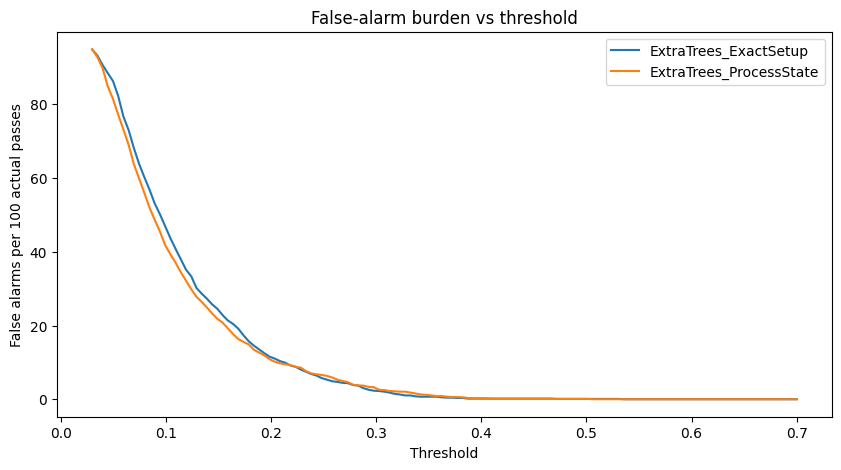

In [13]:
# 11. Threshold optimization for each pipeline

oof_by_model = {}

for name, model in models.items():
    prob = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=outer_cv,
        method="predict_proba",
        n_jobs=1
    )[:, 1]

    oof_by_model[name] = prob

def threshold_table(y_true, probability):
    rows = []

    for threshold in np.linspace(0.03, 0.70, 136):

        pred = (probability >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            pred,
            labels=[0, 1]
        ).ravel()

        precision = precision_score(
            y_true, pred,
            zero_division=0
        )
        recall = recall_score(
            y_true, pred,
            zero_division=0
        )

        rows.append({
            "threshold": threshold,
            "balanced_accuracy": balanced_accuracy_score(
                y_true, pred
            ),
            "recall": recall,
            "precision": precision,
            "f1": f1_score(
                y_true, pred,
                zero_division=0
            ),
            "false_positive_rate": fp / (fp + tn),
            "false_alarms_per_100_passes": (
                100 * fp / max(tn + fp, 1)
            ),
            "missed_failures": fn
        })

    return pd.DataFrame(rows)

thresholds = {}
threshold_details = {}

for name, prob in oof_by_model.items():

    table = threshold_table(
        y_train,
        prob
    )

    # Primary objective:
    # maximize balanced accuracy while avoiding extremely low precision.
    #
    # We first consider operating points with precision >= 15%.
    # If none exists, fall back to pure balanced-accuracy optimization.
    feasible = table[table["precision"] >= 0.15]

    if len(feasible) == 0:
        feasible = table

    best = feasible.sort_values(
        ["balanced_accuracy", "recall", "precision"],
        ascending=[False, False, False]
    ).iloc[0]

    thresholds[name] = float(best["threshold"])
    threshold_details[name] = table

    print(
        name,
        "selected threshold:",
        round(thresholds[name], 3)
    )

# Plot operating-point curves.
plt.figure(figsize=(10, 5))

for name, table in threshold_details.items():
    plt.plot(
        table["threshold"],
        table["false_alarms_per_100_passes"],
        label=name
    )

plt.xlabel("Threshold")
plt.ylabel("False alarms per 100 actual passes")
plt.title("False-alarm burden vs threshold")
plt.legend()
plt.show()


Most frequently selected model: ExtraTrees_ProcessState


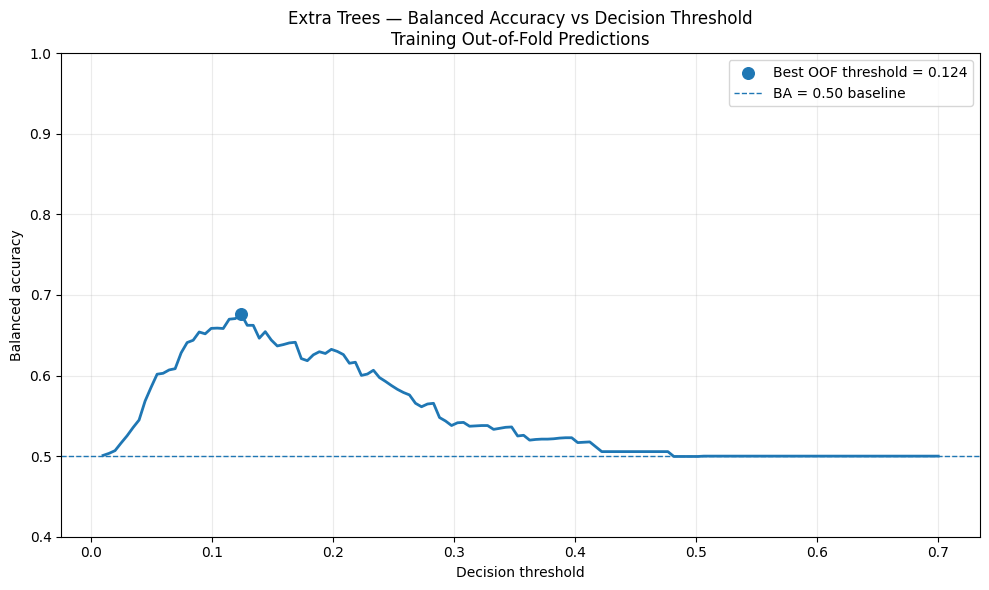

Best OOF threshold: 0.124
Best OOF balanced accuracy: 0.6762


In [14]:
# ============================================================
# BALANCED ACCURACY VS THRESHOLD
# ============================================================
#
# Uses TRAINING OOF probabilities only.
# The untouched test set is never used here.
# ============================================================

# Determine the model selected most frequently across outer folds.
selected_final_model = (
    pd.Series(
        outer_model_choices
    )
    .value_counts()
    .index[0]
)

print(
    "Most frequently selected model:",
    selected_final_model
)

# Generate OOF probabilities for that model on the full training set.
final_oof_probability = cross_val_predict(
    estimator=clone(
        models[selected_final_model]
    ),
    X=X_train,
    y=y_train,
    cv=outer_cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]


threshold_graph_rows = []

for threshold in np.linspace(
    0.01,
    0.70,
    140
):

    prediction = (
        final_oof_probability >= threshold
    ).astype(int)

    threshold_graph_rows.append({
        "threshold": threshold,
        "balanced_accuracy":
            balanced_accuracy_score(
                y_train,
                prediction
            ),
        "recall":
            recall_score(
                y_train,
                prediction,
                zero_division=0
            ),
        "precision":
            precision_score(
                y_train,
                prediction,
                zero_division=0
            ),
        "f1":
            f1_score(
                y_train,
                prediction,
                zero_division=0
            )
    })

threshold_graph_df = pd.DataFrame(
    threshold_graph_rows
)


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_graph_df["threshold"],
    threshold_graph_df["balanced_accuracy"],
    linewidth=2
)

best_idx = (
    threshold_graph_df[
        "balanced_accuracy"
    ].idxmax()
)

best_graph_threshold = float(
    threshold_graph_df.loc[
        best_idx,
        "threshold"
    ]
)

best_graph_ba = float(
    threshold_graph_df.loc[
        best_idx,
        "balanced_accuracy"
    ]
)

plt.scatter(
    [best_graph_threshold],
    [best_graph_ba],
    s=70,
    zorder=5,
    label=(
        f"Best OOF threshold = "
        f"{best_graph_threshold:.3f}"
    )
)

plt.axhline(
    0.50,
    linestyle="--",
    linewidth=1,
    label="BA = 0.50 baseline"
)

plt.xlabel("Decision threshold")
plt.ylabel("Balanced accuracy")
plt.title(
    "Extra Trees — Balanced Accuracy vs Decision Threshold\n"
    "Training Out-of-Fold Predictions"
)

plt.ylim(0.40, 1.00)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


print(
    f"Best OOF threshold: "
    f"{best_graph_threshold:.3f}"
)

print(
    f"Best OOF balanced accuracy: "
    f"{best_graph_ba:.4f}"
)


## 12. Select the preferred operating pipeline

The enhanced process-state pipeline is not automatically accepted.

We prefer it only if it demonstrates stronger/competitive nested-CV and stability results without an unacceptable false-alarm burden.


In [15]:
# 12. Transparent selection summary

summary_rows = []

for name in models:
    temp = stability_df[stability_df["model"] == name]

    row = {
        "model": name,
        "CV_BA_mean": temp["balanced_accuracy"].mean(),
        "CV_BA_std": temp["balanced_accuracy"].std(),
        "CV_ROC_AUC_mean": temp["roc_auc"].mean(),
        "CV_PR_AUC_mean": temp["pr_auc"].mean(),
        "CV_Recall_mean": temp["recall"].mean(),
        "CV_Precision_mean": temp["precision"].mean(),
        "OOF_selected_threshold": thresholds[name]
    }

    summary_rows.append(row)

selection_summary = pd.DataFrame(summary_rows)

display(selection_summary.round(4))

# Primary criterion: mean PR-AUC, then mean balanced accuracy.
preferred_name = (
    selection_summary
    .sort_values(
        ["CV_PR_AUC_mean", "CV_BA_mean"],
        ascending=False
    )
    .iloc[0]["model"]
)

print("Preferred pipeline based on training stability:", preferred_name)


,model,CV_BA_mean,CV_BA_std,CV_ROC_AUC_mean,CV_PR_AUC_mean,CV_Recall_mean,CV_Precision_mean,OOF_selected_threshold
0,ExtraTrees_ExactSetup,0.4995,0.0005,0.7336,0.1640,0.0,0.0,0.1987
1,ExtraTrees_ProcessState,0.4995,0.0007,0.7359,0.1617,0.0,0.0,0.1690


Preferred pipeline based on training stability: ExtraTrees_ExactSetup


## 13. Final fit and untouched test evaluation

Only now do we fit the preferred pipeline to all training data and evaluate the test set.

The test set has not been used for:
- feature selection
- model selection
- threshold selection
- hyperparameter selection


In [16]:
# 13. Final untouched-test evaluation

final_model = clone(models[preferred_name])
final_model.fit(X_train, y_train)

test_probability = final_model.predict_proba(
    X_test
)[:, 1]

final_threshold = thresholds[preferred_name]

test_prediction = (
    test_probability >= final_threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_prediction,
    labels=[0, 1]
).ravel()

final_test = {
    "model": preferred_name,
    "threshold": final_threshold,
    "balanced_accuracy": balanced_accuracy_score(
        y_test, test_prediction
    ),
    "roc_auc": roc_auc_score(
        y_test, test_probability
    ),
    "pr_auc": average_precision_score(
        y_test, test_probability
    ),
    "recall": recall_score(
        y_test, test_prediction,
        zero_division=0
    ),
    "precision": precision_score(
        y_test, test_prediction,
        zero_division=0
    ),
    "f1": f1_score(
        y_test, test_prediction,
        zero_division=0
    ),
    "false_positive_rate": fp / max(fp + tn, 1),
    "false_alarms": fp,
    "missed_failures": fn,
    "true_failures_caught": tp
}

display(pd.DataFrame([final_test]).round(4))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, test_prediction))

print("\nClassification report:")
print(
    classification_report(
        y_test,
        test_prediction,
        target_names=["Pass", "Fail"],
        zero_division=0
    )
)


,model,threshold,balanced_accuracy,roc_auc,pr_auc,recall,precision,f1,false_positive_rate,false_alarms,missed_failures,true_failures_caught
0,ExtraTrees_ExactSetup,0.1987,0.6903,0.8059,0.2718,0.4762,0.2632,0.339,0.0956,28,11,10



Confusion matrix:
[[265  28]
 [ 11  10]]

Classification report:
              precision    recall  f1-score   support

        Pass       0.96      0.90      0.93       293
        Fail       0.26      0.48      0.34        21

    accuracy                           0.88       314
   macro avg       0.61      0.69      0.64       314
weighted avg       0.91      0.88      0.89       314



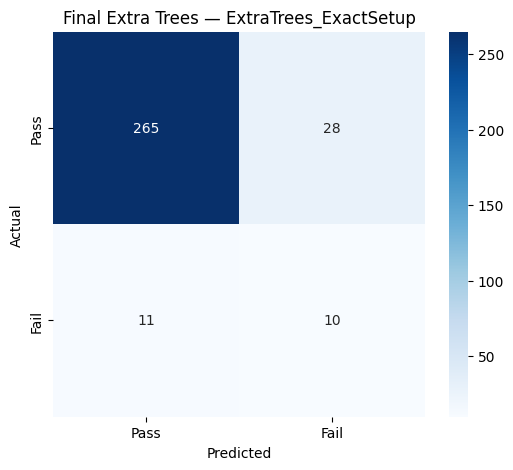

In [17]:
# 14. Test confusion matrix

cm = confusion_matrix(
    y_test,
    test_prediction,
    labels=[0, 1]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pass", "Fail"],
    yticklabels=["Pass", "Fail"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Final Extra Trees — {preferred_name}")
plt.show()


## 15. False-alarm operating-point table on the untouched test set

This is descriptive only. Thresholds below were chosen on training OOF predictions beforehand.

The point is to make the manufacturing trade-off visible:
**higher recall usually means more false alarms.**


In [18]:
# 15. Test operating points

operating_thresholds = sorted(set([
    0.05, 0.075, 0.10, 0.125, 0.15,
    0.20, 0.25, 0.30, final_threshold
]))

operating_rows = []

for threshold in operating_thresholds:
    pred = (test_probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        pred,
        labels=[0, 1]
    ).ravel()

    operating_rows.append({
        "threshold": threshold,
        "balanced_accuracy": balanced_accuracy_score(
            y_test, pred
        ),
        "recall": recall_score(
            y_test, pred,
            zero_division=0
        ),
        "precision": precision_score(
            y_test, pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_test, pred,
            zero_division=0
        ),
        "false_alarms": fp,
        "missed_failures": fn
    })

operating_df = pd.DataFrame(operating_rows).drop_duplicates(
    subset=["threshold"]
).sort_values("threshold")

display(operating_df.round(4))


,threshold,balanced_accuracy,recall,precision,f1,false_alarms,missed_failures
0,0.0500,0.5717,1.0000,0.0772,0.1433,251,0
1,0.0750,0.6299,0.9048,0.0913,0.1659,189,2
2,0.1000,0.7084,0.8571,0.1224,0.2143,129,3
3,0.1250,0.7597,0.8095,0.1667,0.2764,85,4
4,0.1500,0.7513,0.7143,0.1948,0.3061,62,6
5,0.1987,0.6903,0.4762,0.2632,0.3390,28,11
6,0.2000,0.6903,0.4762,0.2632,0.3390,28,11
7,0.2500,0.5748,0.1905,0.2500,0.2162,12,17
8,0.3000,0.5612,0.1429,0.3333,0.2000,6,18


## 16. SHAP explainability

SHAP is applied to the final Extra Trees model.

For a tree ensemble:
- global SHAP summarizes which features most influence predictions overall
- local SHAP explains why a specific sample received a high/low failure score

Because SECOM features are anonymized, interpret these as **model signals**, not physical root causes.


In [19]:
# 16. Prepare final model input for SHAP

selector = final_model.named_steps["selector"]
imputer = final_model.named_steps["imputer"]
tree_model = final_model.named_steps["model"]

# Transform test data exactly as the final model sees it.
X_test_selected = selector.transform(X_test)
X_test_imputed = imputer.transform(X_test_selected)

feature_names_after_imputation = (
    imputer.get_feature_names_out(
        selector.selected_features_
    )
)

X_test_for_shap = pd.DataFrame(
    X_test_imputed,
    columns=feature_names_after_imputation,
    index=X_test.index
)

print("SHAP matrix:", X_test_for_shap.shape)


SHAP matrix: (314, 109)


In [20]:
# 17. SHAP TreeExplainer

explainer = shap.TreeExplainer(tree_model)

# SHAP values for the test set.
shap_values_raw = explainer.shap_values(
    X_test_for_shap
)

# SHAP's binary-class output differs by SHAP version:
# sometimes list[2D arrays], sometimes a 3D ndarray.
if isinstance(shap_values_raw, list):
    shap_values_positive = shap_values_raw[1]
else:
    arr = np.asarray(shap_values_raw)
    if arr.ndim == 3:
        shap_values_positive = arr[:, :, 1]
    else:
        shap_values_positive = arr

print("SHAP values shape:", shap_values_positive.shape)


SHAP values shape: (314, 109)


,feature,mean_abs_shap
0,Sensor_104,0.016184
1,missingindicator_Sensor_346,0.014954
2,missingindicator_Sensor_347,0.012973
3,Sensor_60,0.012699
4,Sensor_500,0.011854
5,Sensor_512,0.011791
6,Sensor_130,0.011141
7,Sensor_511,0.010193
8,Sensor_125,0.009775
9,Sensor_424,0.009301


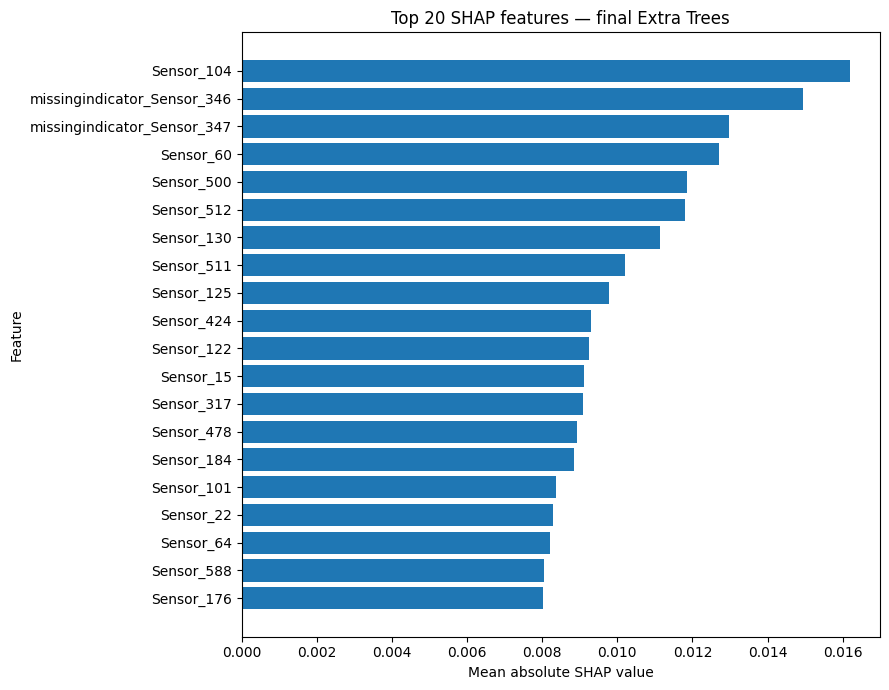

In [21]:
# 18. Global SHAP importance

mean_abs_shap = np.abs(shap_values_positive).mean(axis=0)

shap_importance = (
    pd.DataFrame({
        "feature": X_test_for_shap.columns,
        "mean_abs_shap": mean_abs_shap
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(shap_importance.head(20))

plt.figure(figsize=(9, 7))
top = shap_importance.head(20).sort_values("mean_abs_shap")

plt.barh(
    top["feature"],
    top["mean_abs_shap"]
)

plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.title("Top 20 SHAP features — final Extra Trees")
plt.tight_layout()
plt.show()


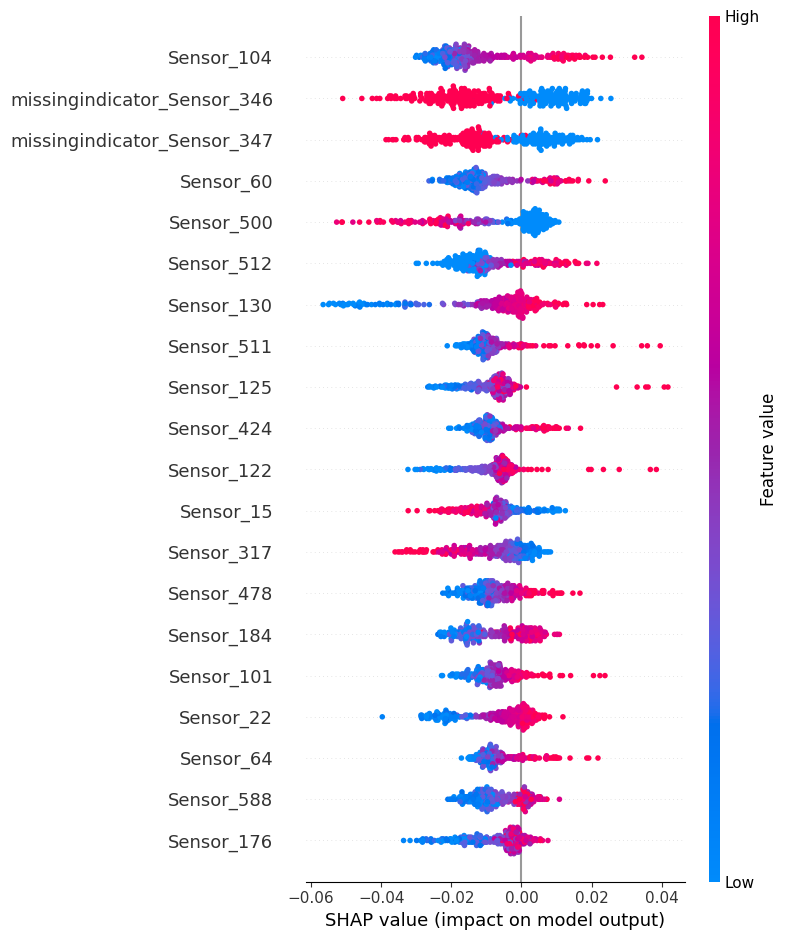

In [22]:
# 19. SHAP summary plot

shap.summary_plot(
    shap_values_positive,
    X_test_for_shap,
    max_display=20,
    show=True
)


## 20. Individual failure investigation with SHAP

Select a test example predicted as failure.

The local explanation answers:
**which features pushed this particular prediction toward failure or pass?**


Test row position: 0
Actual label: 0
Predicted probability: 0.2066
Predicted class: 1


,feature,shap_value,abs_shap,feature_value
38,Sensor_176,-0.029898,0.029898,0.6545
10,Sensor_22,-0.026994,0.026994,-6356.0000
20,Sensor_15,-0.021614,0.021614,12.5732
33,Sensor_512,-0.020927,0.020927,0.0000
12,Sensor_123,-0.016895,0.016895,4.3870
55,Sensor_11,-0.016804,0.016804,-0.0089
21,Sensor_184,-0.015637,0.015637,20.1840
79,missingindicator_Sensor_346,0.015613,0.015613,0.0000
7,Sensor_96,-0.014327,0.014327,0.0000
35,Sensor_418,-0.012820,0.012820,9.5121


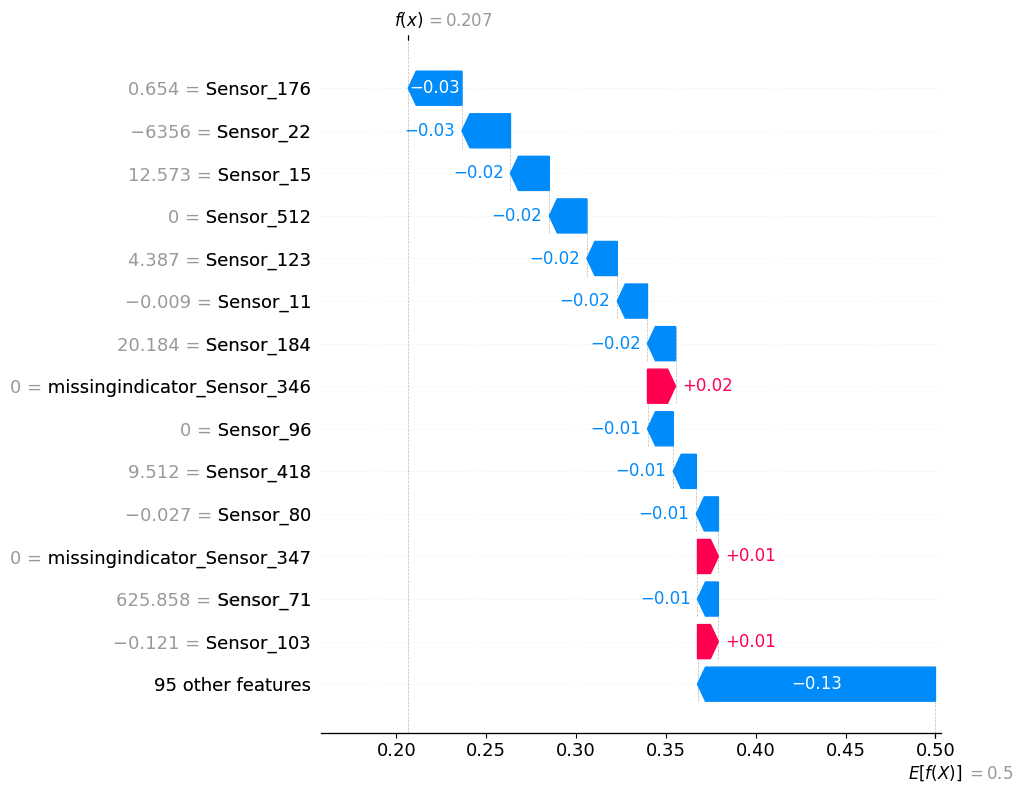

In [23]:
# 20. Explain one predicted-failure sample

failure_indices = np.where(test_prediction == 1)[0]

if len(failure_indices) == 0:
    print("No test sample crossed the selected threshold; local failure SHAP is skipped.")
else:
    local_pos = failure_indices[0]

    print("Test row position:", local_pos)
    print("Actual label:", int(y_test.iloc[local_pos]))
    print("Predicted probability:", round(float(test_probability[local_pos]), 4))
    print("Predicted class:", int(test_prediction[local_pos]))

    local_explanation = (
        pd.DataFrame({
            "feature": X_test_for_shap.columns,
            "shap_value": shap_values_positive[local_pos],
            "abs_shap": np.abs(shap_values_positive[local_pos]),
            "feature_value": X_test_for_shap.iloc[local_pos].values
        })
        .sort_values("abs_shap", ascending=False)
    )

    display(local_explanation.head(20))

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values_positive[local_pos],
            base_values=explainer.expected_value[1]
                if isinstance(explainer.expected_value, (list, np.ndarray))
                else explainer.expected_value,
            data=X_test_for_shap.iloc[local_pos].values,
            feature_names=X_test_for_shap.columns
        ),
        max_display=15,
        show=True
    )


## 21. Candidate process signals: statistics + SHAP

A particularly useful engineering table is the intersection between:
- statistically selected signals
- high SHAP importance

This does **not** prove causality, but it provides a stronger shortlist for engineering investigation.


In [24]:
# 21. Combine statistical selector and SHAP rankings

selected_stats = selector.statistics_[
    selector.statistics_["feature"].isin(
        selector.selected_features_
    )
].copy()

selected_stats = selected_stats[
    ["feature", "p_value", "q_value", "effect", "auc"]
]

# Map imputer names back to original sensor names.
# Imputed original features retain their names; indicators have suffixes.
shap_sensor = shap_importance[
    ~shap_importance["feature"].str.contains(
        "missingindicator",
        case=False,
        na=False
    )
].copy()

shap_sensor["base_feature"] = (
    shap_sensor["feature"]
    .str.replace("x0_", "", regex=False)
)

combined = selected_stats.merge(
    shap_sensor,
    left_on="feature",
    right_on="base_feature",
    how="left"
)

display(
    combined.sort_values(
        ["mean_abs_shap", "q_value"],
        ascending=[False, True]
    ).round(5)
)


,feature_x,p_value,q_value,effect,auc,feature_y,mean_abs_shap,base_feature
0,Sensor_104,0.00000,0.00001,0.79926,0.68147,Sensor_104,0.01618,Sensor_104
1,Sensor_60,0.00000,0.00024,0.41883,0.65998,Sensor_60,0.01270,Sensor_60
44,Sensor_500,0.03200,0.22501,0.00000,0.56448,Sensor_500,0.01185,Sensor_500
33,Sensor_512,0.01726,0.18239,0.84808,0.57226,Sensor_512,0.01179,Sensor_512
6,Sensor_130,0.00017,0.00962,0.11607,0.62319,Sensor_130,0.01114,Sensor_130
3,Sensor_511,0.00002,0.00256,0.37196,0.64102,Sensor_511,0.01019,Sensor_511
17,Sensor_125,0.00702,0.13168,0.36121,0.58837,Sensor_125,0.00977,Sensor_125
48,Sensor_424,0.03649,0.23888,0.22357,0.56861,Sensor_424,0.00930,Sensor_424
54,Sensor_122,0.04440,0.26289,0.10358,0.56590,Sensor_122,0.00924,Sensor_122
20,Sensor_15,0.00846,0.13330,0.26985,0.58638,Sensor_15,0.00911,Sensor_15


# 22. Final conclusion


> **Extra Trees was evaluated under a leakage-controlled pipeline with statistical feature screening, repeated stability analysis, nested model selection, operating-threshold analysis and SHAP explainability. Process-state features were tested rather than assumed to improve performance. SHAP and statistical screening identify candidate process signals for engineering investigation, while physical root-cause claims require domain validation.**
